In [197]:
import ast
import mglearn #library provided by amueller
import numpy as np
import seaborn as sns
%matplotlib inline
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import MultiLabelBinarizer
from sklearn.feature_extraction import FeatureHasher
from sklearn.preprocessing import MinMaxScaler
from sklearn.linear_model import LinearRegression, Ridge, Lasso
pd.options.display.float_format = '{:,.2g}'.format

In [198]:
df = pd.read_csv('games_steam.csv')
df.shape

C:\Users\Drei Abmab\AppData\Local\Temp\ipykernel_13540\957210396.py:1: DtypeWarning: Columns (0: windows, 1: mac, 2: linux, 3: metacritic_score, 4: achievements, 5: recommendations, 6: user_score, 7: positive, 8: negative, 9: average_playtime_forever, 10: average_playtime_2weeks, 11: median_playtime_forever, 12: median_playtime_2weeks, 13: discount, 14: peak_ccu, 15: pct_pos_total, 16: num_reviews_total, 17: pct_pos_recent, 18: num_reviews_recent) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv('games_steam.csv')


(94954, 44)

In [199]:
df.head()

,appid,name,release_date,required_age,price,dlc_count,detailed_description,about_the_game,short_description,reviews,...,average_playtime_2weeks,median_playtime_forever,median_playtime_2weeks,discount,peak_ccu,tags,pct_pos_total,num_reviews_total,pct_pos_recent,num_reviews_recent
0,7.3e+02,Counter-Strike 2,8/21/2012,0,0,1,"For over two decades, Counter-Strike has offer...","For over two decades, Counter-Strike has offer...","For over two decades, Counter-Strike has offer...",NaN,...,879,5174,350,0,1212356,"{'FPS': 90857, 'Shooter': 65397, 'Multiplayer'...",86,8632939,82,96473
1,5.8e+05,PUBG: BATTLEGROUNDS,12/21/2017,0,0,0,"LAND, LOOT, SURVIVE! Play PUBG: BATTLEGROUNDS ...","LAND, LOOT, SURVIVE! Play PUBG: BATTLEGROUNDS ...",Play PUBG: BATTLEGROUNDS for free. Land on str...,NaN,...,0,0,0,0,616738,"{'Survival': 14838, 'Shooter': 12727, 'Battle ...",59,2513842,68,16720
2,5.7e+02,Dota 2,7/9/2013,0,0,2,"The most-played game on Steam. Every day, mill...","The most-played game on Steam. Every day, mill...","Every day, millions of players worldwide enter...",“A modern multiplayer masterpiece.” 9.5/10 – D...,...,1536,898,892,0,555977,"{'Free to Play': 59933, 'MOBA': 20158, 'Multip...",81,2452595,80,29366
3,2.7e+05,Grand Theft Auto V Legacy,4/13/2015,17,0,0,"When a young street hustler, a retired bank ro...","When a young street hustler, a retired bank ro...",Grand Theft Auto V for PC offers players the o...,NaN,...,771,7101,74,0,117698,"{'Open World': 32644, 'Action': 23539, 'Multip...",87,1803832,92,17517
4,4.9e+05,Tom Clancy's Rainbow Six® Siege,12/1/2015,17,20,9,Edition Comparison Ultimate Edition The Tom Cl...,“One of the best first-person shooters ever ma...,"Tom Clancy's Rainbow Six® Siege is an elite, t...",NaN,...,0,0,0,0,0,"{'FPS': 8082, 'Multiplayer': 6139, 'Tactical':...",84,1168404,76,13017


In [200]:
print(df.columns)

Index(['appid', 'name', 'release_date', 'required_age', 'price', 'dlc_count',
       'detailed_description', 'about_the_game', 'short_description',
       'reviews', 'header_image', 'website', 'support_url', 'support_email',
       'windows', 'mac', 'linux', 'metacritic_score', 'achievements',
       'recommendations', 'supported_languages', 'full_audio_languages',
       'packages', 'developers', 'publishers', 'categories', 'genres',
       'screenshots', 'movies', 'user_score', 'positive', 'negative',
       'estimated_owners', 'average_playtime_forever',
       'average_playtime_2weeks', 'median_playtime_forever',
       'median_playtime_2weeks', 'discount', 'peak_ccu', 'tags',
       'pct_pos_total', 'num_reviews_total', 'pct_pos_recent',
       'num_reviews_recent'],
      dtype='str')


In [201]:
df.dtypes


appid                       float64
name                            str
release_date                    str
required_age                float64
price                       float64
dlc_count                   float64
detailed_description            str
about_the_game                  str
short_description               str
reviews                         str
header_image                    str
website                         str
support_url                     str
support_email                   str
windows                      object
mac                          object
linux                        object
metacritic_score             object
achievements                 object
recommendations              object
supported_languages             str
full_audio_languages            str
packages                        str
developers                      str
publishers                      str
categories                      str
genres                          str
screenshots                 

## III. Checking Missing Values

Before training regression models, the dataset must be checked for missing values. Missing values may affect the training process and lead to unreliable results.

In [202]:
df.isna().sum()

appid                          10
name                           13
release_date                   11
required_age                   11
price                          11
dlc_count                      11
detailed_description         5436
about_the_game               5460
short_description            5359
reviews                     84523
header_image                   10
website                     53762
support_url                 50771
support_email               16105
windows                         7
mac                             6
linux                           6
metacritic_score                6
achievements                    6
recommendations                 5
supported_languages          5416
full_audio_languages        55093
packages                    19079
developers                   5455
publishers                   5784
categories                   5911
genres                       5445
screenshots                  3457
movies                       7669
user_score    

## IV. Data Cleaning

The dataset is cleaned to make it suitable for regression modeling.

The following cleaning steps are performed:
- removing unnecessary columns
- trimming extra spaces from column names and values
- removing dirty text patterns and symbols
- dropping rows with remaining missing values after cleaning



In [203]:
df = df.loc[:, ~df.columns.str.contains('^Unnamed')]
df.isna().sum()

appid                          10
name                           13
release_date                   11
required_age                   11
price                          11
dlc_count                      11
detailed_description         5436
about_the_game               5460
short_description            5359
reviews                     84523
header_image                   10
website                     53762
support_url                 50771
support_email               16105
windows                         7
mac                             6
linux                           6
metacritic_score                6
achievements                    6
recommendations                 5
supported_languages          5416
full_audio_languages        55093
packages                    19079
developers                   5455
publishers                   5784
categories                   5911
genres                       5445
screenshots                  3457
movies                       7669
user_score    

In [204]:
print(df.shape)

(94954, 44)


In [205]:
df_clean = df.copy()

# Remove extra spaces from column names
df_clean.columns = df_clean.columns.str.strip()

# Remove columns with too many missing values (> 20,000 NaNs)
# This helps improve data quality by dropping features that are
# too sparse to be useful for analysis or machine learning.
# Rows are NOT affected.
threshold = 20000
df_clean = df_clean.loc[:, df.isna().sum() <= threshold]

# Drop Colunms because it is not relevant
cols_to_drop = [
    "appid",
    "screenshots",
    "about_the_game",
    "short_description",
    "website",
    "support_url",
    "support_email",
    "movies",
    "header_image",
    "release_date",
    "detailed_description",
    "header_image",
    "packages",
    "average_playtime_2weeks ",
    "median_playtime_forever",
    "median_playtime_2weeks",
    "positive",
    "negative",
    "pct_pos_total",
    "pct_pos_recent",
    "num_reviews_total",
    "num_reviews_recent",
    "peak_ccu",
    "recommendations",
]

df_clean = df_clean.drop(columns=cols_to_drop, errors="ignore")


def clean_numeric_series(series):
    return pd.to_numeric(
        series.astype(str)
        .str.strip()
        .str.replace(r"^id_", "", regex=True)
        .str.replace(r"_x$", "", regex=True)
        .str.replace("$", "", regex=False)
        .str.replace("%", "", regex=False)
        .str.replace(",", "", regex=False)
        .str.replace("abc", "", regex=False)
        .replace("nan", np.nan),
        errors="coerce"
    )

numeric_cols = df_clean.select_dtypes(include=np.number).columns

df_clean[numeric_cols] = df_clean[numeric_cols].fillna(
    df_clean[numeric_cols].median()
)

print("Shape after cleaning and conversion:", df_clean.shape)
print("\nMissing values after conversion:\n")
print(df_clean.isnull().sum().sort_values(ascending=False).head(20))



Shape after cleaning and conversion: (94954, 19)

Missing values after conversion:

categories                  5911
publishers                  5784
developers                  5455
genres                      5445
supported_languages         5416
name                          13
windows                        7
linux                          6
metacritic_score               6
achievements                   6
mac                            6
average_playtime_2weeks        4
average_playtime_forever       4
estimated_owners               4
user_score                     4
discount                       4
required_age                   0
price                          0
dlc_count                      0
dtype: int64


In [206]:
df_clean = df_clean.dropna()

print("Final cleaned shape:", df_clean.shape)
print("\nRemaining missing values:\n")
print(df_clean.isnull().sum().sort_values(ascending=False).head(20))


Final cleaned shape: (88131, 19)

Remaining missing values:

name                        0
required_age                0
price                       0
dlc_count                   0
windows                     0
mac                         0
linux                       0
metacritic_score            0
achievements                0
supported_languages         0
developers                  0
publishers                  0
categories                  0
genres                      0
user_score                  0
estimated_owners            0
average_playtime_forever    0
average_playtime_2weeks     0
discount                    0
dtype: int64


In [207]:
print(df_clean.columns)

Index(['name', 'required_age', 'price', 'dlc_count', 'windows', 'mac', 'linux',
       'metacritic_score', 'achievements', 'supported_languages', 'developers',
       'publishers', 'categories', 'genres', 'user_score', 'estimated_owners',
       'average_playtime_forever', 'average_playtime_2weeks', 'discount'],
      dtype='str')


### Converting values

In [208]:
bool_cols = ["windows", "mac", "linux"]

# convert true and false values to 1's and 0's
df_clean[bool_cols] = df_clean[bool_cols].apply(
    lambda col: col.astype(str).str.strip().str.upper().map({
        "TRUE": 1,
        "FALSE": 0
    })
)

In [209]:
list_cols = ["supported_languages", "developers", "publishers", "categories", "genres"]

for col in list_cols:
    df_clean[col] = df_clean[col].apply(lambda x: ast.literal_eval(x) if isinstance(x, str) else x)

In [210]:
mlb = MultiLabelBinarizer()

lang_encoded = mlb.fit_transform(df_clean["supported_languages"])

lang_df = pd.DataFrame(lang_encoded, columns=[f"lang_{c}" for c in mlb.classes_])

df_clean = df_clean.join(lang_df)

In [211]:
top_devs = df_clean["developers"].explode().value_counts().head(100).index

df_clean["developers_filtered"] = df_clean["developers"].apply(
    lambda x: [i for i in x if i in top_devs]
)

mlb = MultiLabelBinarizer()
dev_encoded = mlb.fit_transform(df_clean["developers_filtered"])

dev_df = pd.DataFrame(dev_encoded, columns=[f"dev_{c}" for c in mlb.classes_], index=df_clean.index)

df_clean = pd.concat([df_clean, dev_df], axis=1)

In [212]:
top_pub = df_clean["publishers"].explode().value_counts().head(100).index

df_clean["publishers_filtered"] = df_clean["publishers"].apply(
    lambda x: [i for i in x if i in top_pub]
)

mlb_pub = MultiLabelBinarizer()

pub_encoded = mlb_pub.fit_transform(df_clean["publishers_filtered"])

pub_df = pd.DataFrame(
    pub_encoded,
    columns=[f"pub_{c}" for c in mlb_pub.classes_],
    index=df_clean.index
)

df_clean = pd.concat([df_clean, pub_df], axis=1)

In [213]:
mlb_cat = MultiLabelBinarizer()

cat_encoded = mlb_cat.fit_transform(df_clean["categories"])

cat_df = pd.DataFrame(
    cat_encoded,
    columns=[f"cat_{c}" for c in mlb_cat.classes_],
    index=df_clean.index
)

df_clean = pd.concat([df_clean, cat_df], axis=1)

In [214]:
mlb_gen = MultiLabelBinarizer()

gen_encoded = mlb_gen.fit_transform(df_clean["genres"])

gen_df = pd.DataFrame(
    gen_encoded,
    columns=[f"genre_{c}" for c in mlb_gen.classes_],
    index=df_clean.index
)

df_clean = pd.concat([df_clean, gen_df], axis=1)

In [215]:
df_clean = df_clean.drop(columns=["supported_languages", "developers", "publishers", "categories", "genres"])

In [216]:
df_clean

,name,required_age,price,dlc_count,windows,mac,linux,metacritic_score,achievements,user_score,...,genre_Short,genre_Simulation,genre_Software Training,genre_Sports,genre_Strategy,genre_Tutorial,genre_Utilities,genre_Video Production,genre_Violent,genre_Web Publishing
0,Counter-Strike 2,0,0,1,1,0,1,0,1,0,...,0,0,0,0,0,0,0,0,0,0
1,PUBG: BATTLEGROUNDS,0,0,0,1,0,0,0,37,0,...,0,0,0,0,0,0,0,0,0,0
2,Dota 2,0,0,2,1,1,1,90,0,0,...,0,0,0,0,1,0,0,0,0,0
3,Grand Theft Auto V Legacy,17,0,0,1,0,0,96,77,0,...,0,0,0,0,0,0,0,0,0,0
4,Tom Clancy's Rainbow Six® Siege,17,20,9,1,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
94949,Outrun Them,0,4,0,1,0,0,0,6,0,...,0,0,0,0,0,0,0,0,0,0
94950,Lands of Pharaoh: Episode 1,0,10,0,1,0,0,0,0,0,...,0,0,0,0,1,0,0,0,0,0
94951,Player One,0,2,0,1,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
94952,DragonRoad,0,30,0,1,0,0,0,34,0,...,0,1,0,0,1,0,0,0,0,0


In [217]:
df_clean.dtypes

name                          str
required_age              float64
price                     float64
dlc_count                 float64
windows                     int64
                           ...   
genre_Tutorial              int64
genre_Utilities             int64
genre_Video Production      int64
genre_Violent               int64
genre_Web Publishing        int64
Length: 396, dtype: object

## V. Correlation 
To visualize the strength and direction of relationships among the variables, we use the correlation heatmap.


) missing from font(s) DejaVu Sans.nts\Coding Projects\41_50\42_Linear_Regression\.venv\Lib\site-packages\seaborn\utils.py:61: UserWarning: Glyph 13 (
  fig.canvas.draw()
) missing from font(s) DejaVu Sans.nts\Coding Projects\41_50\42_Linear_Regression\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 13 (
  fig.canvas.print_figure(bytes_io, **kw)


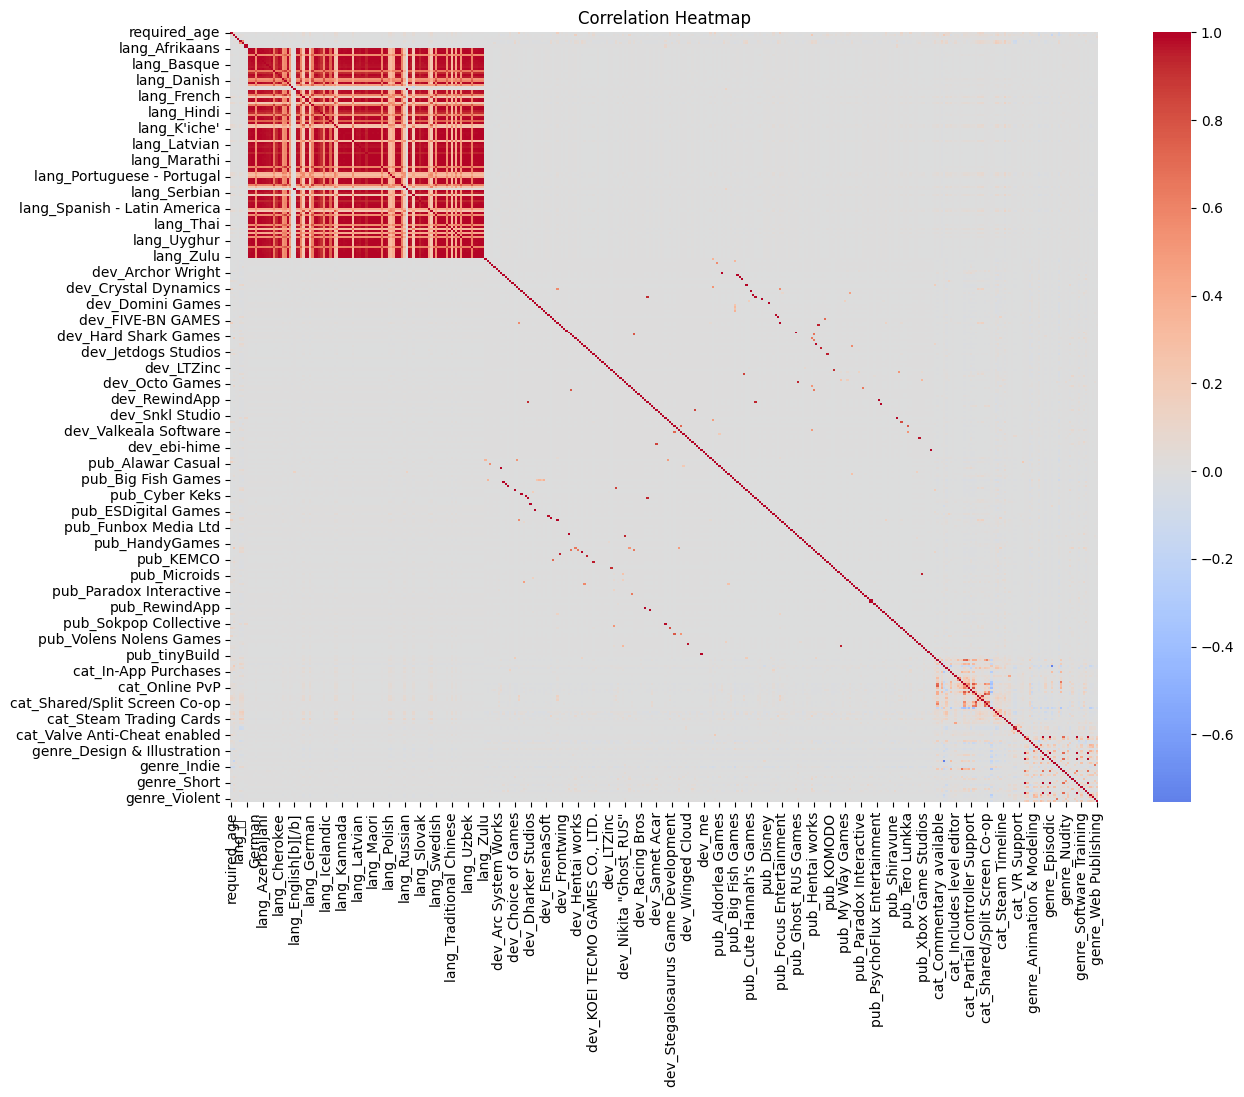

In [218]:
plt.figure(figsize=(14, 10))
sns.heatmap(df_clean.corr(numeric_only=True), cmap="coolwarm", center=0)
plt.title("Correlation Heatmap")
plt.show()


The correlation analysis shows that many variables are still highly correlated with each other, particularly those derived from similar financial indicators such as Open, High, Low, Close, and related features across different indices.



In [219]:
numeric_df = df_clean.select_dtypes(include=['number'])

corr_matrix = numeric_df.corr()
threshold = 0.9

print("Strongly Correlated Feature Pairs:\n")

for i in range(len(corr_matrix.columns)):
    for j in range(i + 1, len(corr_matrix.columns)):
        corr_value = corr_matrix.iloc[i, j]

        if corr_value > threshold or corr_value < -threshold:
            col1 = corr_matrix.columns[i]
            col2 = corr_matrix.columns[j]
            print(f"{col1} <--> {col2} : {corr_value:.2f}")

Strongly Correlated Feature Pairs:

lang_
French <--> lang_
German : 1.00
lang_Afrikaans <--> lang_Albanian : 0.98
lang_Afrikaans <--> lang_Amharic : 0.98
lang_Afrikaans <--> lang_Armenian : 0.98
lang_Afrikaans <--> lang_Assamese : 0.98
lang_Afrikaans <--> lang_Azerbaijani : 0.98
lang_Afrikaans <--> lang_Bangla : 0.97
lang_Afrikaans <--> lang_Basque : 0.97
lang_Afrikaans <--> lang_Belarusian : 0.97
lang_Afrikaans <--> lang_Bosnian : 0.98
lang_Afrikaans <--> lang_Catalan : 0.93
lang_Afrikaans <--> lang_Cherokee : 0.98
lang_Afrikaans <--> lang_Croatian : 0.96
lang_Afrikaans <--> lang_Dari : 0.98
lang_Afrikaans <--> lang_Estonian : 0.98
lang_Afrikaans <--> lang_Filipino : 0.96
lang_Afrikaans <--> lang_Galician : 0.98
lang_Afrikaans <--> lang_Georgian : 0.98
lang_Afrikaans <--> lang_Gujarati : 0.98
lang_Afrikaans <--> lang_Hausa : 0.98
lang_Afrikaans <--> lang_Hebrew : 0.96
lang_Afrikaans <--> lang_Hindi : 0.91
lang_Afrikaans <--> lang_Icelandic : 0.98
lang_Afrikaans <--> lang_Igbo : 0.99


In [220]:
df_model = df_clean.copy()

In [221]:
print(df_model['average_playtime_forever'].dtype)

object


In [222]:
# Separate target
target_col = "average_playtime_forever"

# Ensure the target is numeric before filtering
df_model[target_col] = pd.to_numeric(df_model[target_col], errors='coerce')
df_model = df_model.dropna(subset=[target_col])

# Filter out zero-playtime rows — they're noise, not signal
df_model = df_model[df_model[target_col] > 0]

# log-transform the remaining non-zero values
df_model[target_col] = np.log1p(df_model[target_col])

# Keep only numeric columns
df_model = df_model.select_dtypes(include=['number'])
df_model = df_model.dropna()

# Compute correlation matrix
corr_matrix = df_model.corr().abs()

# Upper triangle (avoid duplicate pairs)
upper = corr_matrix.where(
    np.triu(np.ones(corr_matrix.shape), k=1).astype(bool)
)

threshold = 0.9

to_drop = []

for column in upper.columns:
    for row in upper.index:
        if (upper.loc[row, column] > threshold and column != target_col and row != target_col):
            to_drop.append(column)
            break

# Drop highly correlated columns
df_model = df_model.drop(columns=set(to_drop))

print("Dropped columns:")
print(to_drop)

print("\nNew shape:", df_model.shape)

Dropped columns:
['lang_\r\nGerman', 'lang_Albanian', 'lang_Amharic', 'lang_Armenian', 'lang_Assamese', 'lang_Azerbaijani', 'lang_Bangla', 'lang_Basque', 'lang_Bosnian', 'lang_Cherokee', 'lang_Dari', 'lang_Estonian', 'lang_Filipino', 'lang_Galician', 'lang_Georgian', 'lang_Gujarati', 'lang_Hausa', 'lang_Hebrew', 'lang_Icelandic', 'lang_Igbo', 'lang_Irish', "lang_K'iche'", 'lang_Kannada', 'lang_Kazakh', 'lang_Khmer', 'lang_Kinyarwanda', 'lang_Konkani', 'lang_Kyrgyz', 'lang_Latvian', 'lang_Lithuanian', 'lang_Luxembourgish', 'lang_Macedonian', 'lang_Malay', 'lang_Malayalam', 'lang_Maltese', 'lang_Maori', 'lang_Marathi', 'lang_Mongolian', 'lang_Nepali', 'lang_Odia', 'lang_Persian', 'lang_Punjabi (Gurmukhi)', 'lang_Punjabi (Shahmukhi)', 'lang_Quechua', 'lang_Scots', 'lang_Serbian', 'lang_Sindhi', 'lang_Sinhala', 'lang_Slovenian', 'lang_Sorani', 'lang_Sotho', 'lang_Swahili', 'lang_Tajik', 'lang_Tamil', 'lang_Tatar', 'lang_Telugu', 'lang_Tigrinya', 'lang_Tswana', 'lang_Turkmen', 'lang_Urdu', 

Again, with threshold of 0.9, let's check the highly correlated pairs:

In [ ]:
numeric_df = df_model.select_dtypes(include=['number'])

corr_matrix = numeric_df.corr()
threshold = 0.9

print("Strongly Correlated Feature Pairs:\n")

for i in range(len(corr_matrix.columns)):
    for j in range(i + 1, len(corr_matrix.columns)):
        corr_value = corr_matrix.iloc[i, j]

        if corr_value > threshold or corr_value < -threshold:
            col1 = corr_matrix.columns[i]
            col2 = corr_matrix.columns[j]
            print(f"{col1} <--> {col2} : {corr_value:.2f}")


) missing from font(s) DejaVu Sans.nts\Coding Projects\41_50\42_Linear_Regression\.venv\Lib\site-packages\seaborn\utils.py:61: UserWarning: Glyph 13 (
  fig.canvas.draw()
) missing from font(s) DejaVu Sans.nts\Coding Projects\41_50\42_Linear_Regression\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 13 (
  fig.canvas.print_figure(bytes_io, **kw)


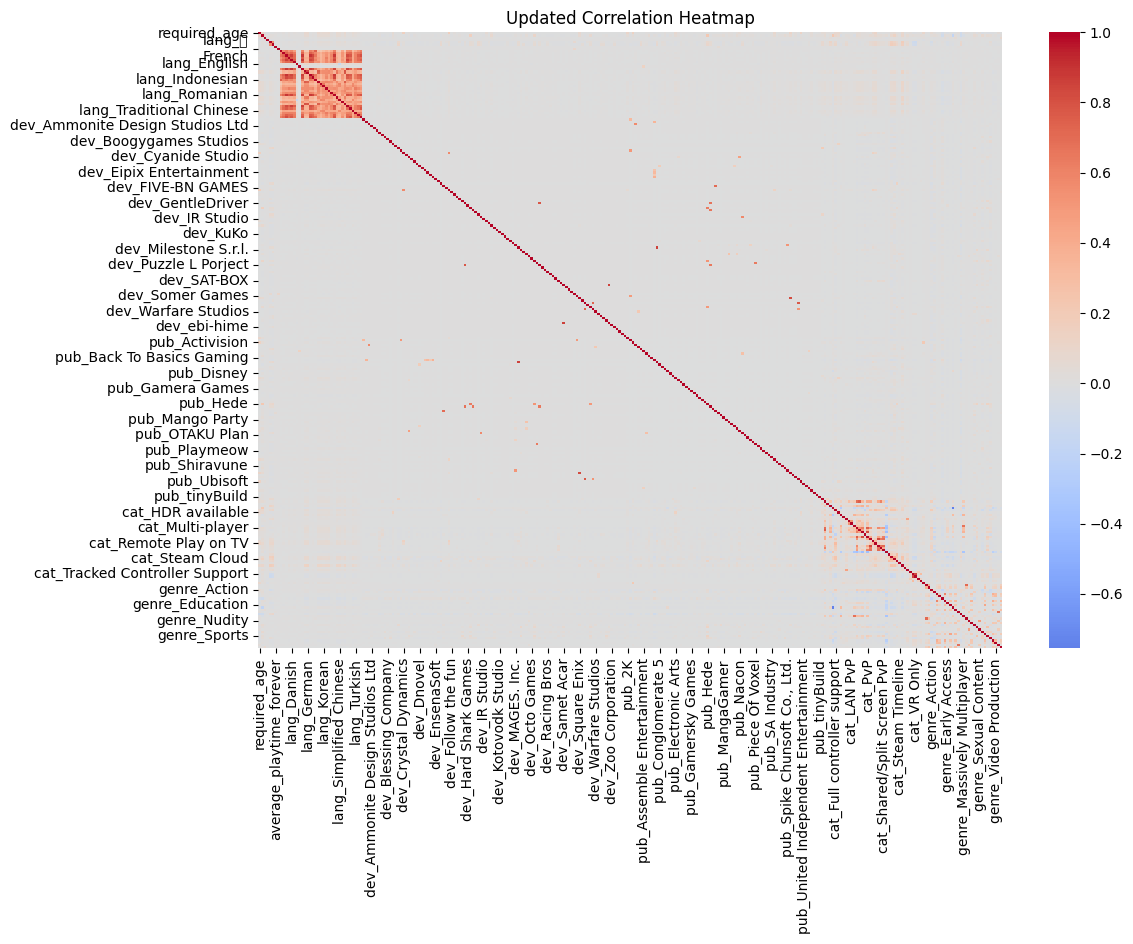

In [ ]:
plt.figure(figsize=(12, 8))
sns.heatmap(df_model.corr(), cmap="coolwarm", center=0)
plt.title("Updated Correlation Heatmap")
plt.show()

In [ ]:
print(df_model.columns)

Index(['required_age', 'price', 'dlc_count', 'windows', 'mac', 'linux',
       'average_playtime_forever', 'lang_\r\nFrench', 'lang_Afrikaans',
       'lang_Arabic',
       ...
       'genre_Racing', 'genre_Sexual Content', 'genre_Simulation',
       'genre_Software Training', 'genre_Sports', 'genre_Strategy',
       'genre_Utilities', 'genre_Video Production', 'genre_Violent',
       'genre_Web Publishing'],
      dtype='str', length=279)


## VI. Normalization and Identifying the target
Min-Max normalization was applied to the dataset by first converting the cleaned and reduced dataset into a NumPy array and then scaling it using the MinMaxScaler.

The normalized values were then converted back into a DataFrame with the original column names preserved.

After normalization, the predictor variables and the target variable were separated. The target variable is **average_playtime_forever**, while the remaining columns were used as predictor features.

This ensures that all features are on a comparable scale before applying regression models.

In [ ]:
mms = MinMaxScaler()
ex = np.array(df_model)

X_norm = mms.fit_transform(ex)

df_norm = pd.DataFrame(X_norm)
df_norm.columns = df_model.columns

X = df_norm.drop(columns=['average_playtime_forever'])
y = df_norm['average_playtime_forever']

### Now, let's proceed to Linear regression, Ridge and Lasso.

## VII. Linear Regression
Linear Regression is used as the baseline model to understand the relationship between the predictor variables and the target variable.

The model is trained multiple times using different random states to ensure that the evaluation is reliable and not dependent on a single train-test split.

The average training and testing scores are computed to assess how well the model fits the data and generalizes to unseen data.

In [ ]:
training_accuracy = []
test_accuracy = []
coeff = []

for rs in range(0, 100):
    X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=rs)

    model = LinearRegression()
    model.fit(X_train, y_train)

    training_accuracy.append(model.score(X_train, y_train))
    test_accuracy.append(model.score(X_test, y_test))
    coeff.append(model.coef_)

print("Average Training Score:", np.mean(training_accuracy))
print("Average Test Score:", np.mean(test_accuracy))

lin_train = training_accuracy.copy()
lin_test = test_accuracy.copy()

Average Training Score: 0.006854627657986874
Average Test Score: -0.12837403056197305


The model achieved an **average training score of approximately `0.961` and an average test score of approximately `0.958`**. The small difference between these values indicates that the model is **not overfitting** and is able to generalize well to unseen data. These results suggest that the selected features have a strong linear relationship with the target variable (`USO_Adj Close`), allowing the model to make accurate predictions.

### Linear Regression Coefficient Plot

In [ ]:
# Average coefficients
fin_lst = []

for i in range(len(X.columns)):
    tmp_ = []
    for lst in coeff:
        tmp_.append(lst[i])
    fin_lst.append(np.mean(tmp_))

pd.DataFrame({
    "Variables": X.columns,
    "Weights": fin_lst
})

,Variables,Weights
0,required_age,0.00019
1,price,0.00044
2,dlc_count,0.0035
3,windows,3.8e-05
4,mac,-3.6e-05
...,...,...
273,genre_Strategy,-2.9e-05
274,genre_Utilities,0.00041
275,genre_Video Production,2e-06
276,genre_Violent,0.00025


C:\Users\Drei Abmab\AppData\Local\Temp\ipykernel_13540\3515238276.py:11: UserWarning: Glyph 27225 (\N{CJK UNIFIED IDEOGRAPH-6A59}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\Drei Abmab\AppData\Local\Temp\ipykernel_13540\3515238276.py:11: UserWarning: Glyph 20809 (\N{CJK UNIFIED IDEOGRAPH-5149}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\Drei Abmab\AppData\Local\Temp\ipykernel_13540\3515238276.py:11: UserWarning: Glyph 28216 (\N{CJK UNIFIED IDEOGRAPH-6E38}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\Drei Abmab\AppData\Local\Temp\ipykernel_13540\3515238276.py:11: UserWarning: Glyph 25103 (\N{CJK UNIFIED IDEOGRAPH-620F}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
) missing from font(s) DejaVu Sans.emp\ipykernel_13540\3515238276.py:11: UserWarning: Glyph 13 (
  plt.tight_layout()
c:\Users\Drei Abmab\OneDrive\Documents\Coding Projects\41_50\42_Linear_Regression\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: 

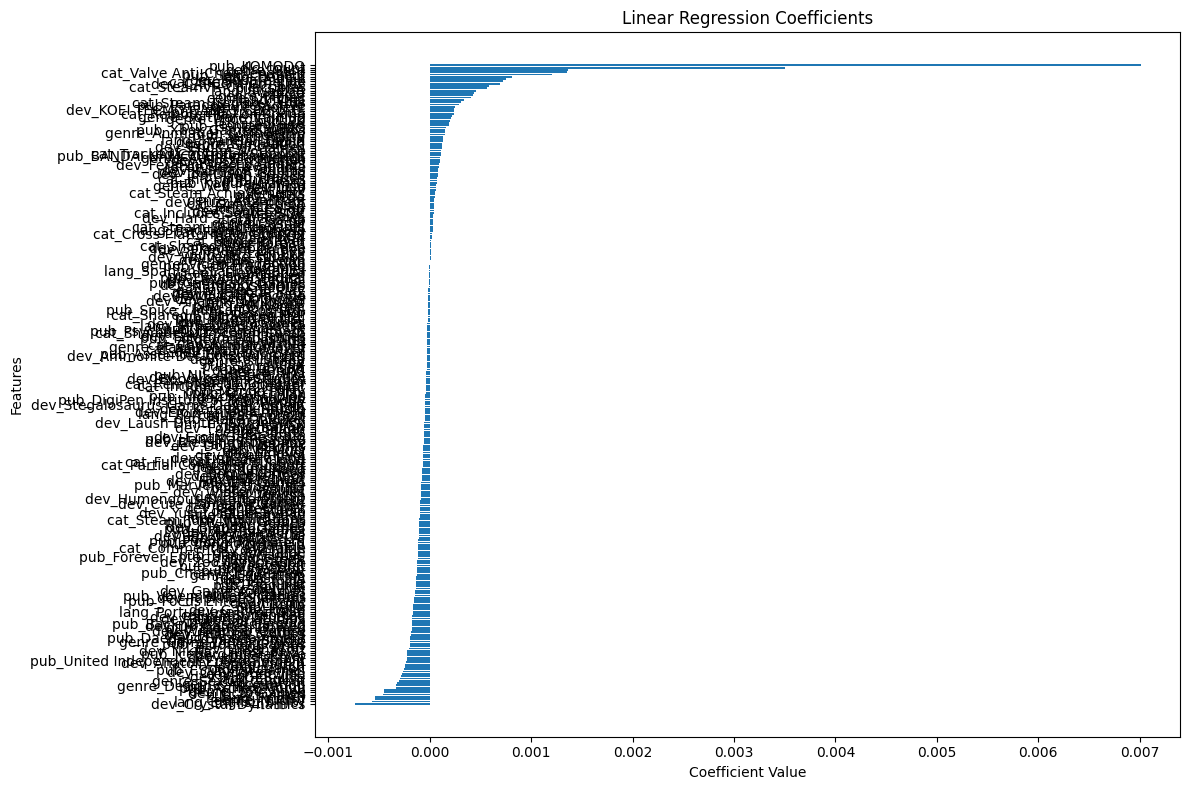

In [ ]:
coef_df = pd.DataFrame({
    "Variables": X.columns,
    "Weights": fin_lst
}).sort_values("Weights")

plt.figure(figsize=(12, 8))
plt.barh(coef_df["Variables"], coef_df["Weights"])
plt.title("Linear Regression Coefficients")
plt.xlabel("Coefficient Value")
plt.ylabel("Features")
plt.tight_layout()
plt.show()

The coefficients of the model were also averaged across all iterations to identify the overall influence of each feature. Positive coefficients indicate that the feature increases the target value, while negative coefficients indicate a decreasing effect.

Overall, the Linear Regression model demonstrates strong predictive performance and serves as a solid baseline for comparison with Ridge and Lasso regression models.

## VIII. Ridge regression


Ridge Regression is a regularized version of Linear Regression that applies an L2 penalty to the coefficients.

This helps reduce the magnitude of the coefficients and makes the model more stable, especially when the predictor variables are correlated.

To determine the best value of alpha, multiple alpha values are tested. For each alpha, the model is trained and evaluated using 100 different train-test splits. The average training and testing scores are then computed and plotted.

In [ ]:
plt.figure(figsize = (20,10))

alpha_ridge = [1e-12, 1e-10, 1e-8, 1e-4, 1e-3, 0.1, 0.2, 0.4, 0.75, 1, 1.5, 3, 5, 10, 15, 20]

fin_train = []
fin_test = []

for alpha in alpha_ridge:
    training_accuracy = []
    test_accuracy = []
    
    for rs in range(0,100):
        X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=rs)
        
        clf = Ridge(alpha=alpha).fit(X_train, y_train)
        
        training_accuracy.append(clf.score(X_train, y_train))
        test_accuracy.append(clf.score(X_test, y_test))
    
    fin_train.append(sum(training_accuracy)/len(training_accuracy))
    fin_test.append(sum(test_accuracy)/len(test_accuracy))

plt.plot(alpha_ridge, fin_train, label="training accuracy", marker='.')
plt.plot(alpha_ridge, fin_test, label="test accuracy", marker='.')
plt.ylabel("Accuracy")
plt.xlabel("Alpha")
plt.xticks(alpha_ridge, rotation=90)
plt.legend()
plt.show()

c:\Users\Drei Abmab\OneDrive\Documents\Coding Projects\41_50\42_Linear_Regression\.venv\Lib\site-packages\sklearn\linear_model\_ridge.py:228: LinAlgWarning: An ill-conditioned matrix detected: slice 0 has rcond = 7.788399487197387e-18.
  return linalg.solve(A, Xy, assume_a="pos", overwrite_a=True).T
c:\Users\Drei Abmab\OneDrive\Documents\Coding Projects\41_50\42_Linear_Regression\.venv\Lib\site-packages\sklearn\linear_model\_ridge.py:228: LinAlgWarning: An ill-conditioned matrix detected: slice 0 has rcond = 7.793400827091216e-18.
  return linalg.solve(A, Xy, assume_a="pos", overwrite_a=True).T
c:\Users\Drei Abmab\OneDrive\Documents\Coding Projects\41_50\42_Linear_Regression\.venv\Lib\site-packages\sklearn\linear_model\_ridge.py:228: LinAlgWarning: An ill-conditioned matrix detected: slice 0 has rcond = 7.7395630893667e-18.
  return linalg.solve(A, Xy, assume_a="pos", overwrite_a=True).T
c:\Users\Drei Abmab\OneDrive\Documents\Coding Projects\41_50\42_Linear_Regression\.venv\Lib\site-pa

KeyboardInterrupt: 

<Figure size 2000x1000 with 0 Axes>

The graph above shows how the average training and testing scores change as the value of alpha increases.

When alpha is very small, Ridge Regression behaves similarly to ordinary Linear Regression. As alpha increases, stronger regularization is applied, shrinking the coefficients more strongly.

The best alpha is the one that gives the highest testing score, since this indicates the best generalization performance.

In [ ]:
best_alpha_ridge = alpha_ridge[np.argmax(fin_test)]
best_ridge_test_score = max(fin_test)

print("Best alpha for Ridge:", best_alpha_ridge)
print("Best average test score:", best_ridge_test_score)

The best performance was achieved at **alpha = 0.1**, with an average test score of **approximately 0.9588.**

This result indicates that a moderate amount of regularization was beneficial for improving model stability and generalization. Overall, Ridge Regression provides a stable model with strong predictive performance, while slightly controlling the magnitude of the coefficients.

### Ridge Regression Coefficients

After identifying the best alpha value, the coefficients of the Ridge Regression model are plotted **using bar chart**. This helps show how strongly each feature contributes to the prediction after regularization has been applied.

In [ ]:
training_accuracy = []
test_accuracy = []
coeff = []

for rs in range(0, 100):
    X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=rs)

    ridge_best = Ridge(alpha=best_alpha_ridge)
    ridge_best.fit(X_train, y_train)

    training_accuracy.append(model.score(X_train, y_train))
    test_accuracy.append(model.score(X_test, y_test))
    coeff.append(model.coef_)

print("Average Training Score:", np.mean(training_accuracy))
print("Average Test Score:", np.mean(test_accuracy))

lin_train = training_accuracy.copy()
lin_test = test_accuracy.copy()



In [ ]:
# Average coefficients
fin_lst = []

for i in range(len(X.columns)):
    tmp_ = []
    for lst in coeff:
        tmp_.append(lst[i])
    fin_lst.append(np.mean(tmp_))

pd.DataFrame({
    "Variables": X.columns,
    "Weights": fin_lst
})

In [ ]:
coef_df = pd.DataFrame({
    "Variables": X.columns,
    "Weights": fin_lst
}).sort_values("Weights")

plt.figure(figsize=(12, 8))
plt.barh(coef_df["Variables"], coef_df["Weights"])
plt.title("Ridge Regression Coefficients")
plt.xlabel("Coefficient Value")
plt.ylabel("Features")
plt.tight_layout()
plt.show()

The coefficient bar chart shows the weights of each feature in the Ridge Regression model using the selected alpha value of 0.1. Most coefficients are relatively small and centered around zero, and we think that the model has successfully reduced the influence of individual predictors through regularization. This, we think, reduce overfitting.

Positive coefficients indicate that the corresponding feature increases the predicted value of the target variable, while negative coefficients indicate a decreasing effect.

**Overall, Ridge Regression maintains all features while controlling their magnitude, resulting in a more stable and reliable model.**

## IX. Lasso Regression 

Lasso Regression is a regularized version of Linear Regression that applies an L1 penalty.

Different values of alpha are tested to determine the best level of regularization. The model is trained and evaluated multiple times using different random states, and the average training and testing scores are computed.

In [ ]:
plt.figure(figsize = (20,10))

alpha_lasso = [1e-12, 1e-10, 1e-8, 1e-6, 1e-4, 1e-3, 1e-2, 0.05, 0.1]

fin_train = []
fin_test = []

for alpha in alpha_lasso:
    training_accuracy = []
    test_accuracy = []
    
    for rs in range(0,100):
        X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=rs)
        clf = Lasso(alpha=alpha, max_iter=100000).fit(X_train, y_train)
        training_accuracy.append(clf.score(X_train, y_train))
        test_accuracy.append(clf.score(X_test, y_test))
    
    fin_train.append(sum(training_accuracy)/len(training_accuracy))
    fin_test.append(sum(test_accuracy)/len(test_accuracy))

    fin_train_lasso = fin_train
    fin_test_lasso = fin_test

plt.plot(alpha_lasso, fin_train, label="training accuracy", marker='.')
plt.plot(alpha_lasso, fin_test, label="test accuracy", marker='.')
plt.ylabel("Accuracy")
plt.xlabel("Alpha")
plt.xticks(alpha_lasso, rotation=90)
plt.legend()
plt.show()

The graph above shows how the average training and testing scores change as the value of alpha increases in Lasso Regression.

At small alpha values, the model achieves high accuracy, similar to Linear Regression. As alpha increases, the accuracy gradually decreases because stronger regularization is applied.

Lasso reduces the number of active features by shrinking some coefficients to zero. While this helps simplify the model, too much regularization can remove important features, leading to lower performance.

Therefore, the best alpha is the one that provides the highest testing score while maintaining a balance between model simplicity and predictive accuracy.

In [ ]:
best_alpha_lasso = alpha_lasso[np.argmax(fin_test)]
best_lasso_test_score = max(fin_test)

print("Best alpha for Lasso:", best_alpha_lasso)
print("Best average test score:", best_lasso_test_score)

The Lasso Regression model achieved its best performance at alpha = 0.0001, with an average test score of approximately 0.9589.

This indicates that a small amount of regularization was optimal, as higher alpha values reduced model performance. At this optimal alpha, Lasso maintains strong predictive accuracy while slightly simplifying the model by shrinking less important feature coefficients.

### Lasso Regression Coefficient Plot


In [ ]:
lasso_best = Lasso(alpha=best_alpha_lasso)
lasso_best.fit(X_train, y_train)

coef_df_lasso = pd.DataFrame({
    "Variables": X.columns,
    "Weights": lasso_best.coef_
}).sort_values("Weights")

plt.figure(figsize=(12, 8))
plt.barh(coef_df_lasso["Variables"], coef_df_lasso["Weights"])
plt.title(f"Lasso Coefficients (alpha={best_alpha_lasso})")
plt.xlabel("Coefficient Value")
plt.ylabel("Features")
plt.tight_layout()
plt.show()

The Lasso coefficient plot shows that some features have coefficients equal to zero, meaning they were completely removed from the model. This demonstrates Lasso’s ability to perform feature selection, simplifying the model while maintaining strong predictive performance.

In [ ]:
print("Number of features used:", np.sum(lasso_best.coef_ != 0))

The Lasso Regression model retained 22 features out of the total predictors, indicating that most variables still contribute to predicting the target variable.

Unlike typical Lasso behavior where many coefficients become exactly zero, this result suggests that the dataset contains features that all carry meaningful information, even after correlation-based feature selection. As seen in the coefficient plot, only a few features have coefficients very close to zero, while most remain active with varying levels of influence.

The most influential features include EU_Price, USB_Price, and PLD_Price, which have the largest positive coefficients, indicating a strong positive relationship with the target variable. On the other hand, SP_open and DJ_volume have large negative coefficients, suggesting an inverse relationship with the target.

So we ask, "why only 1 feature was removed?" - This behavior indicates that prior preprocessing steps, particularly correlation-based feature removal, already minimized redundancy in the dataset. As a result, Lasso focuses more on coefficient shrinkage rather than aggressive feature elimination.

Overall, Lasso was able to slightly reduce model complexity while preserving most of the important predictors. This indicates that the dataset is already well-optimized after removing highly correlated features, leaving minimal redundancy for Lasso to eliminate.